ر# Temporal Accident Detection

## Objective

The goal of this notebook is to classify each video as **positive** or **negative** for an accident.

Accident detection is a temporal problem. A single frame may show cars and a road, but an accident is usually identified from changes across several consecutive frames. For this reason, the model uses two stages:

1. **ResNet18** extracts a 512-dimensional visual feature vector from every frame.
2. **GRU or LSTM** reads the ordered sequence of frame features and produces one prediction for the complete video.

The notebook performs four experiments:

1. Frozen ResNet18 with GRU
2. Five-fold cross-validation for the baseline GRU
3. Fine-tuning only `layer4` of ResNet18 with GRU
4. Frozen ResNet18 with LSTM

Cross-validation is used to measure model stability and the average train-validation gap. The final comparison uses validation accuracy, Macro F1, validation loss, and overfitting indicators.

No test data is used. Google Drive is used to read the labeled data and processed frames. At the end, only the selected GRU model and its validation predictions are saved to Drive.

## 1. Environment Setup

This section mounts Google Drive, imports the required libraries, selects the available device, and fixes the random seed. A GPU is recommended because every video contains many frames and ResNet18 processes each frame separately.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import gc
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
)
from torchvision.models import (
    resnet18,
    ResNet18_Weights,
)

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [ ]:
SEED = 42


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Project Paths

The labeled CSV files and processed frames are read from the project folder on Google Drive. Experiment checkpoints remain temporary inside the Colab runtime. The two final delivery paths are also defined here, but Drive is not written until the final export cell.

In [ ]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/AI_Project2"
)

CV_DIR = PROJECT_ROOT / "outputs" / "cv"
FRAMES_ROOT = CV_DIR / "frames_processed"

TRAIN_CSV = CV_DIR / "train_split.csv"
VAL_CSV = CV_DIR / "validation_split.csv"

MODEL_DIR = PROJECT_ROOT / "models" / "cv"
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BASELINE_GRU_PATH = (
    MODEL_DIR
    / "best_frozen_resnet_gru_checkpoint.pth"
)

FINAL_MODEL_PATH = (
    MODEL_DIR
    / "temporal_model.pth"
)

FINAL_PREDICTIONS_PATH = (
    CV_DIR
    / "temporal_validation_predictions.csv"
)

print("Frames folder exists:", FRAMES_ROOT.exists())
print("Train CSV exists:", TRAIN_CSV.exists())
print("Validation CSV exists:", VAL_CSV.exists())
print("Checkpoint path:", BASELINE_GRU_PATH)
print("Final model path:", FINAL_MODEL_PATH)
print("Final predictions path:", FINAL_PREDICTIONS_PATH)

Frames folder exists: True
Train CSV exists: True
Validation CSV exists: True
Checkpoint path: /content/drive/MyDrive/AI_Project2/models/cv/best_frozen_resnet_gru_checkpoint.pth
Final model path: /content/drive/MyDrive/AI_Project2/models/cv/temporal_model.pth
Final predictions path: /content/drive/MyDrive/AI_Project2/outputs/cv/temporal_validation_predictions.csv


## 3. Load and Validate the Official Split

The checks confirm that labels are valid and that the same video does not appear in both splits. Keeping complete videos in one split prevents data leakage between train and validation.

In [ ]:
train_df = pd.read_csv(
    TRAIN_CSV,
    dtype={"video_id": str},
)

val_df = pd.read_csv(
    VAL_CSV,
    dtype={"video_id": str},
)

train_df["video_id"] = (
    train_df["video_id"].astype(str).str.zfill(5)
)

val_df["video_id"] = (
    val_df["video_id"].astype(str).str.zfill(5)
)

print("Train rows:", len(train_df))
print("Validation rows:", len(val_df))

print("Train videos:", train_df["video_id"].nunique())
print("Validation videos:", val_df["video_id"].nunique())

shared_video_ids = (
    set(train_df["video_id"])
    & set(val_df["video_id"])
)

print("Shared video IDs:", len(shared_video_ids))

assert len(shared_video_ids) == 0, (
    "Video leakage was found between train and validation."
)

Train rows: 5972
Validation rows: 1618
Train videos: 80
Validation videos: 20
Shared video IDs: 0


## 4. Build and Check Frame Paths

Each CSV row represents one frame. The actual image path is reconstructed from the split name, class label, zero-padded video ID, and frame index. Missing paths are checked before training starts.

In [ ]:
def build_actual_path(row):
    video_id = str(row["video_id"]).zfill(5)
    frame_index = int(row["frame_index"])

    return (
        FRAMES_ROOT
        / str(row["split"])
        / str(row["class"])
        / video_id
        / f"{frame_index:06d}.jpg"
    )


train_df["actual_path"] = train_df.apply(
    build_actual_path,
    axis=1,
)

val_df["actual_path"] = val_df.apply(
    build_actual_path,
    axis=1,
)

missing_train = (
    ~train_df["actual_path"]
    .apply(lambda path: Path(path).exists())
).sum()

missing_val = (
    ~val_df["actual_path"]
    .apply(lambda path: Path(path).exists())
).sum()

print("Missing train frames:", missing_train)
print("Missing validation frames:", missing_val)

assert missing_train == 0
assert missing_val == 0

Missing train frames: 0
Missing validation frames: 0


## 5. Image Preprocessing

Every frame is resized to `224 × 224`, converted to a tensor, and normalized with ImageNet statistics because the feature extractor uses pretrained ResNet18 weights.

Training videos may receive a horizontal flip. The same flip decision is applied to every frame of one video so the temporal sequence remains consistent. Validation videos are not augmented.

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    ),
])

## 6. Video Dataset

The CSV contains one row per frame, but the model needs one item per video. The custom dataset groups rows by `video_id`, sorts frames by `frame_index`, loads the complete ordered sequence, and returns:

- a tensor containing all frames of the video,
- one video-level label,
- the video ID.

Videos can contain different numbers of frames, so their sequence lengths are preserved for later use by GRU or LSTM.

In [ ]:
LABEL_TO_INDEX = {
    "negative": 0,
    "positive": 1,
}

INDEX_TO_LABEL = {
    0: "negative",
    1: "positive",
}


class NexarVideoDataset(Dataset):

    def __init__(
        self,
        df,
        transform=None,
        augment=False,
    ):
        self.df = df.copy()
        self.transform = transform
        self.augment = augment

        self.df["video_id"] = (
            self.df["video_id"]
            .astype(str)
            .str.zfill(5)
        )

        self.df["target"] = (
            self.df["label"]
            .astype(str)
            .str.strip()
            .str.lower()
            .map(LABEL_TO_INDEX)
        )

        if self.df["target"].isna().any():
            unknown_labels = (
                self.df.loc[
                    self.df["target"].isna(),
                    "label",
                ]
                .drop_duplicates()
                .tolist()
            )

            raise ValueError(
                f"Unknown labels: {unknown_labels}"
            )

        self.df["target"] = (
            self.df["target"].astype(int)
        )

        self.video_groups = []

        grouped_videos = self.df.groupby(
            "video_id",
            sort=False,
        )

        for video_id, video_df in grouped_videos:

            video_df = (
                video_df
                .sort_values("frame_index")
                .reset_index(drop=True)
            )

            unique_labels = (
                video_df["target"].unique()
            )

            if len(unique_labels) != 1:
                raise ValueError(
                    f"Video {video_id} has "
                    f"inconsistent labels."
                )

            self.video_groups.append(video_df)

    def __len__(self):
        return len(self.video_groups)

    def __getitem__(self, index):

        video_df = self.video_groups[index]
        video_id = video_df["video_id"].iloc[0]


        apply_flip = (
            self.augment
            and random.random() < 0.5
        )

        frames = []

        for _, row in video_df.iterrows():

            frame_path = Path(row["actual_path"])

            try:
                with Image.open(frame_path) as image:
                    image = image.convert("RGB")

            except Exception as error:
                print(
                    f"Warning: failed to load "
                    f"{frame_path}: {error}"
                )

                image = Image.new(
                    mode="RGB",
                    size=(320, 180),
                    color=0,
                )

            if apply_flip:
                image = TF.hflip(image)

            if self.transform is not None:
                image = self.transform(image)

            frames.append(image)

        frames = torch.stack(
            frames,
            dim=0,
        )

        label = torch.tensor(
            int(video_df["target"].iloc[0]),
            dtype=torch.long,
        )

        return frames, label, video_id


def temporal_collate_fn(batch):

    sequences, labels, video_ids = zip(*batch)

    lengths = torch.tensor(
        [
            sequence.shape[0]
            for sequence in sequences
        ],
        dtype=torch.long,
    )

    padded_frames = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=0.0,
    )

    labels = torch.stack(labels)

    max_length = padded_frames.shape[1]
    frame_positions = torch.arange(max_length)

    padding_mask = (
        frame_positions.unsqueeze(0)
        < lengths.unsqueeze(1)
    )

    return (
        padded_frames,
        labels,
        lengths,
        padding_mask,
        list(video_ids),
    )

## 7. DataLoaders and Variable-Length Batches

A batch may contain videos with different sequence lengths. The custom collate function pads shorter videos only to the longest video in that batch. The original lengths are passed to `pack_padded_sequence`, so GRU and LSTM ignore padded positions.

`BATCH_SIZE = 2` is used because full video sequences require considerable GPU memory.

`NUM_WORKERS` controls how many background processes load images. It is set to `0` in this final notebook for stable reading from Google Drive. This can be slightly slower, but avoids common multiprocessing errors in Colab.

In [ ]:
BATCH_SIZE = 2
NUM_WORKERS = 2


def make_video_loaders(
    train_data,
    val_data,
    seed,
):
    train_dataset = NexarVideoDataset(
        df=train_data,
        transform=train_transforms,
        augment=True,
    )

    val_dataset = NexarVideoDataset(
        df=val_data,
        transform=val_transforms,
        augment=False,
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=temporal_collate_fn,
    )

    val_loader = DataLoader(
        dataset=val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        collate_fn=temporal_collate_fn,
    )

    return (
        train_dataset,
        val_dataset,
        train_loader,
        val_loader,
    )


(
    train_dataset,
    val_dataset,
    train_loader,
    val_loader,
) = make_video_loaders(
    train_data=train_df,
    val_data=val_df,
    seed=SEED,
)

print("Train dataset videos:", len(train_dataset))
print("Validation dataset videos:", len(val_dataset))

Train dataset videos: 80
Validation dataset videos: 20


## 8. ResNet18 Feature Extractor

The final ImageNet classification layer is replaced with an identity layer. ResNet18 then converts every frame into a 512-dimensional visual feature vector.

Two configurations are supported:

- `fine_tune_layer4=False`: the complete ResNet18 is frozen.
- `fine_tune_layer4=True`: only the final residual block, `layer4`, is trainable.

ResNet18 stays in evaluation mode during training so BatchNorm statistics remain fixed. This is important because the batch size is very small.

In [ ]:
class ResNet18FeatureExtractor(nn.Module):

    def __init__(
        self,
        fine_tune_layer4=False,
    ):
        super().__init__()

        self.fine_tune_layer4 = (
            fine_tune_layer4
        )

        self.resnet = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        self.resnet.fc = nn.Identity()

        # Freeze the full ResNet first.
        for parameter in self.resnet.parameters():
            parameter.requires_grad = False

        # Optionally train only the last block.
        if self.fine_tune_layer4:
            for parameter in (
                self.resnet.layer4.parameters()
            ):
                parameter.requires_grad = True

    def forward(self, videos):

        batch_size = videos.shape[0]
        sequence_length = videos.shape[1]

        frames = videos.reshape(
            batch_size * sequence_length,
            3,
            224,
            224,
        )

        features = self.resnet(frames)

        features = features.reshape(
            batch_size,
            sequence_length,
            512,
        )

        return features


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

## 9. Temporal Models

GRU and LSTM receive the ordered sequence of 512-dimensional frame features. `pack_padded_sequence` removes the effect of padding. The final hidden state summarizes the video and is passed to a linear classifier with two outputs.

Both models use one recurrent layer and hidden size `128` so their comparison is fair.

In [ ]:
class GRUTemporalModel(nn.Module):

    def __init__(
        self,
        input_size=512,
        hidden_size=128,
        num_classes=2,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(self, features, lengths):

        packed_features = pack_padded_sequence(
            features,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, hidden = self.gru(
            packed_features
        )

        video_features = hidden[-1]

        return self.classifier(
            video_features
        )


class LSTMTemporalModel(nn.Module):

    def __init__(
        self,
        input_size=512,
        hidden_size=128,
        num_classes=2,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
        )

        self.classifier = nn.Linear(
            hidden_size,
            num_classes,
        )

    def forward(self, features, lengths):

        packed_features = pack_padded_sequence(
            features,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, (hidden, cell) = self.lstm(
            packed_features
        )

        video_features = hidden[-1]

        return self.classifier(
            video_features
        )

## 10. Training Procedure

The training function handles both frozen and fine-tuned feature extractors.

For a frozen ResNet18, frame features are computed without gradients. During layer4 fine-tuning, gradients are allowed to update the final ResNet block.

The best checkpoint is selected using:

1. higher validation accuracy,
2. lower validation loss when validation accuracy is equal.

Early stopping ends training when this score does not improve for the selected patience. The train accuracy from the same best epoch is stored so the train-validation gap can be measured.

In [ ]:
def score_is_better(
    val_accuracy,
    val_loss,
    best_accuracy,
    best_loss,
    min_delta,
):
    accuracy_improved = (
        val_accuracy > best_accuracy + 1e-12
    )

    same_accuracy_better_loss = (
        abs(val_accuracy - best_accuracy) <= 1e-12
        and
        val_loss < best_loss - min_delta
    )

    return (
        accuracy_improved
        or same_accuracy_better_loss
    )


def train_temporal_experiment(
    temporal_model,
    feature_extractor,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    checkpoint_path,
    max_epochs,
    patience,
    min_delta,
    fine_tune_cnn=False,
    experiment_name="Experiment",
):

    checkpoint_path = Path(checkpoint_path)

    if checkpoint_path.exists():
        checkpoint_path.unlink()

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    best_accuracy = -1.0
    best_loss = float("inf")
    best_epoch = 0
    best_train_accuracy = 0.0

    epochs_without_improvement = 0

    feature_extractor.eval()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    start_time = time.time()

    for epoch in range(max_epochs):

        # -------------------------
        # Training
        # -------------------------
        temporal_model.train()


        feature_extractor.eval()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for (
            frames,
            labels,
            lengths,
            mask,
            video_ids,
        ) in train_loader:

            frames = frames.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()

            if fine_tune_cnn:
                features = feature_extractor(
                    frames
                )
            else:
                with torch.no_grad():
                    features = feature_extractor(
                        frames
                    )

            outputs = temporal_model(
                features,
                lengths,
            )

            loss = criterion(
                outputs,
                labels,
            )

            loss.backward()
            optimizer.step()

            train_loss_sum += (
                loss.item() * labels.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            train_correct += (
                predictions == labels
            ).sum().item()

            train_total += labels.size(0)

        train_loss = (
            train_loss_sum / train_total
        )

        train_accuracy = (
            train_correct / train_total
        )

        # -------------------------
        # Validation
        # -------------------------
        temporal_model.eval()
        feature_extractor.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for (
                frames,
                labels,
                lengths,
                mask,
                video_ids,
            ) in val_loader:

                frames = frames.to(device)
                labels = labels.to(device).long()

                features = feature_extractor(
                    frames
                )

                outputs = temporal_model(
                    features,
                    lengths,
                )

                loss = criterion(
                    outputs,
                    labels,
                )

                val_loss_sum += (
                    loss.item() * labels.size(0)
                )

                predictions = outputs.argmax(
                    dim=1
                )

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_loss = (
            val_loss_sum / val_total
        )

        val_accuracy = (
            val_correct / val_total
        )

        history["train_loss"].append(
            train_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        print(
            f"{experiment_name} | "
            f"Epoch {epoch + 1}/{max_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Accuracy: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Accuracy: {val_accuracy:.4f}"
        )

        improved = score_is_better(
            val_accuracy=val_accuracy,
            val_loss=val_loss,
            best_accuracy=best_accuracy,
            best_loss=best_loss,
            min_delta=min_delta,
        )

        if improved:

            best_accuracy = val_accuracy
            best_loss = val_loss
            best_epoch = epoch + 1
            best_train_accuracy = train_accuracy

            epochs_without_improvement = 0

            checkpoint = {
                "temporal_model_state_dict":
                    temporal_model.state_dict(),
                "best_epoch": best_epoch,
                "best_val_accuracy":
                    best_accuracy,
                "best_val_loss":
                    best_loss,
                "train_accuracy_at_best":
                    best_train_accuracy,
            }

            if fine_tune_cnn:
                checkpoint[
                    "feature_extractor_state_dict"
                ] = feature_extractor.state_dict()

            torch.save(
                checkpoint,
                checkpoint_path,
            )

            print(
                "Best score checkpoint saved"
            )

        else:

            epochs_without_improvement += 1

            print(
                "Epochs without score improvement:",
                epochs_without_improvement,
            )

        if (
            epochs_without_improvement
            >= patience
        ):
            print("Early stopping")
            break

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    training_minutes = (
        time.time() - start_time
    ) / 60

    summary = {
        "best_epoch": best_epoch,
        "best_val_accuracy": best_accuracy,
        "best_val_loss": best_loss,
        "train_accuracy_at_best":
            best_train_accuracy,
        "train_val_gap":
            best_train_accuracy - best_accuracy,
        "training_minutes":
            training_minutes,
    }

    print()
    print("Best epoch:", best_epoch)
    print(
        "Best validation accuracy:",
        round(best_accuracy, 4),
    )
    print(
        "Validation loss at best score:",
        round(best_loss, 4),
    )
    print(
        "Train accuracy at best score:",
        round(best_train_accuracy, 4),
    )
    print(
        "Train-validation gap:",
        round(
            summary["train_val_gap"],
            4,
        ),
    )
    print(
        "Training time:",
        round(training_minutes, 2),
        "minutes",
    )

    return history, summary


def load_best_checkpoint(
    temporal_model,
    feature_extractor,
    checkpoint_path,
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    temporal_model.load_state_dict(
        checkpoint[
            "temporal_model_state_dict"
        ]
    )

    if (
        "feature_extractor_state_dict"
        in checkpoint
    ):
        feature_extractor.load_state_dict(
            checkpoint[
                "feature_extractor_state_dict"
            ]
        )

    temporal_model.eval()
    feature_extractor.eval()

    return checkpoint

## 11. Evaluation and Overfitting Indicators

The evaluation functions calculate validation loss, accuracy, Macro F1, class-level precision and recall, confusion matrix, prediction confidence, and positive-class probability.

Training curves show how train and validation performance change across epochs. A growing difference between train and validation performance is an overfitting warning.

The train-validation gap labels are simple practical diagnostics for this small project, not formal statistical tests.

In [ ]:
def evaluate_temporal_model(
    temporal_model,
    feature_extractor,
    data_loader,
    criterion,
):

    temporal_model.eval()
    feature_extractor.eval()

    all_labels = []
    all_predictions = []
    all_confidences = []
    all_positive_probabilities = []
    all_video_ids = []

    loss_sum = 0.0
    total = 0

    with torch.no_grad():

        for (
            frames,
            labels,
            lengths,
            mask,
            video_ids,
        ) in data_loader:

            frames = frames.to(device)
            labels = labels.to(device).long()

            features = feature_extractor(
                frames
            )

            outputs = temporal_model(
                features,
                lengths,
            )

            loss = criterion(
                outputs,
                labels,
            )

            probabilities = torch.softmax(
                outputs,
                dim=1,
            )

            predictions = probabilities.argmax(
                dim=1
            )

            confidences = probabilities.max(
                dim=1
            ).values

            positive_probabilities = (
                probabilities[:, 1]
            )

            loss_sum += (
                loss.item() * labels.size(0)
            )

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )

            all_confidences.extend(
                confidences.cpu().tolist()
            )

            all_positive_probabilities.extend(
                positive_probabilities
                .cpu()
                .tolist()
            )

            all_video_ids.extend(video_ids)

    metrics = {
        "loss": loss_sum / total,
        "accuracy": accuracy_score(
            all_labels,
            all_predictions,
        ),
        "macro_f1": f1_score(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0,
        ),
    }

    predictions_df = pd.DataFrame({
        "video_id": all_video_ids,
        "true_label": [
            INDEX_TO_LABEL[label]
            for label in all_labels
        ],
        "predicted_label": [
            INDEX_TO_LABEL[label]
            for label in all_predictions
        ],
        "predicted_probability":
            all_confidences,
        "positive_probability":
            all_positive_probabilities,
    })

    return (
        metrics,
        predictions_df,
        all_labels,
        all_predictions,
    )


def show_evaluation(
    experiment_name,
    metrics,
    labels,
    predictions,
):

    print(experiment_name)
    print(
        "Validation Loss:",
        round(metrics["loss"], 4),
    )
    print(
        "Validation Accuracy:",
        round(metrics["accuracy"], 4),
    )
    print(
        "Macro F1:",
        round(metrics["macro_f1"], 4),
    )
    print()

    print(
        classification_report(
            labels,
            predictions,
            labels=[0, 1],
            target_names=[
                "Negative",
                "Positive",
            ],
            digits=4,
            zero_division=0,
        )
    )

    cm = confusion_matrix(
        labels,
        predictions,
        labels=[0, 1],
    )

    cm_display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Negative",
            "Positive",
        ],
    )

    cm_display.plot()
    plt.title(
        f"{experiment_name} Confusion Matrix"
    )
    plt.show()


def plot_training_history(
    history,
    best_epoch,
    experiment_name,
):

    epochs = range(
        1,
        len(history["train_loss"]) + 1,
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss",
    )

    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Validation Loss",
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label="Best Epoch",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        f"{experiment_name}: Loss"
    )
    plt.legend()
    plt.grid()
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Train Accuracy",
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy",
    )

    plt.axvline(
        best_epoch,
        linestyle="--",
        label="Best Epoch",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        f"{experiment_name}: Accuracy"
    )
    plt.legend()
    plt.grid()
    plt.show()


def describe_overfitting(gap):
    # This is a simple diagnostic, not a formal proof.
    if gap >= 0.15:
        return (
            "Strong overfitting warning: "
            "the train-validation accuracy gap "
            "is large."
        )

    if gap >= 0.08:
        return (
            "Moderate overfitting warning: "
            "the train result is noticeably "
            "higher than validation."
        )

    return (
        "The train-validation accuracy gap "
        "is relatively small."
    )

## 12. Shared Training Settings

The same epoch limit, patience, loss function, hidden size, and temporal-model learning rate are used for GRU and LSTM. The fine-tuned ResNet block uses a much smaller learning rate because its pretrained visual features should change gradually.

In [18]:
MAX_EPOCHS = 10
PATIENCE = 5
MIN_DELTA = 0.0

TEMPORAL_LEARNING_RATE = 1e-3
FINETUNE_LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.0

criterion = nn.CrossEntropyLoss()

print("Maximum epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print(
    "Temporal learning rate:",
    TEMPORAL_LEARNING_RATE,
)
print(
    "Layer4 fine-tuning learning rate:",
    FINETUNE_LEARNING_RATE,
)
print("Weight decay:", WEIGHT_DECAY)

Maximum epochs: 10
Patience: 5
Temporal learning rate: 0.001
Layer4 fine-tuning learning rate: 1e-05
Weight decay: 0.0


# Experiment 1: Frozen ResNet18 + GRU

This is the baseline experiment. ResNet18 is used only as a fixed frame-level feature extractor. The GRU and its classifier are the only trainable parts.

### Baseline Model Setup

This cell creates a new frozen ResNet18 feature extractor, a new GRU model, and an Adam optimizer for the GRU parameters.

In [19]:
set_seed(SEED)

baseline_feature_extractor = (
    ResNet18FeatureExtractor(
        fine_tune_layer4=False
    ).to(device)
)

baseline_gru = GRUTemporalModel().to(
    device
)

baseline_optimizer = torch.optim.Adam(
    baseline_gru.parameters(),
    lr=TEMPORAL_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(
    "Trainable ResNet parameters:",
    count_trainable_parameters(
        baseline_feature_extractor
    ),
)

print(
    "Trainable GRU parameters:",
    count_trainable_parameters(
        baseline_gru
    ),
)

Trainable ResNet parameters: 0
Trainable GRU parameters: 246786


In [20]:
(
    baseline_history,
    baseline_summary,
) = train_temporal_experiment(
    temporal_model=baseline_gru,
    feature_extractor=(
        baseline_feature_extractor
    ),
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=baseline_optimizer,
    criterion=criterion,
    checkpoint_path=BASELINE_GRU_PATH,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    fine_tune_cnn=False,
    experiment_name=(
        "Frozen ResNet18 + GRU"
    ),
)

Frozen ResNet18 + GRU | Epoch 1/10 | Train Loss: 0.8212 | Train Accuracy: 0.5000 | Val Loss: 0.6521 | Val Accuracy: 0.6000
Best score checkpoint saved
Frozen ResNet18 + GRU | Epoch 2/10 | Train Loss: 0.5707 | Train Accuracy: 0.7125 | Val Loss: 0.5984 | Val Accuracy: 0.7500
Best score checkpoint saved
Frozen ResNet18 + GRU | Epoch 3/10 | Train Loss: 0.5203 | Train Accuracy: 0.7375 | Val Loss: 0.6966 | Val Accuracy: 0.6000
Epochs without score improvement: 1
Frozen ResNet18 + GRU | Epoch 4/10 | Train Loss: 0.4707 | Train Accuracy: 0.7625 | Val Loss: 0.6919 | Val Accuracy: 0.5000
Epochs without score improvement: 2
Frozen ResNet18 + GRU | Epoch 5/10 | Train Loss: 0.3467 | Train Accuracy: 0.8375 | Val Loss: 0.5569 | Val Accuracy: 0.7000
Epochs without score improvement: 3
Frozen ResNet18 + GRU | Epoch 6/10 | Train Loss: 0.2645 | Train Accuracy: 0.9250 | Val Loss: 0.5583 | Val Accuracy: 0.7000
Epochs without score improvement: 4
Frozen ResNet18 + GRU | Epoch 7/10 | Train Loss: 0.2518 | Trai

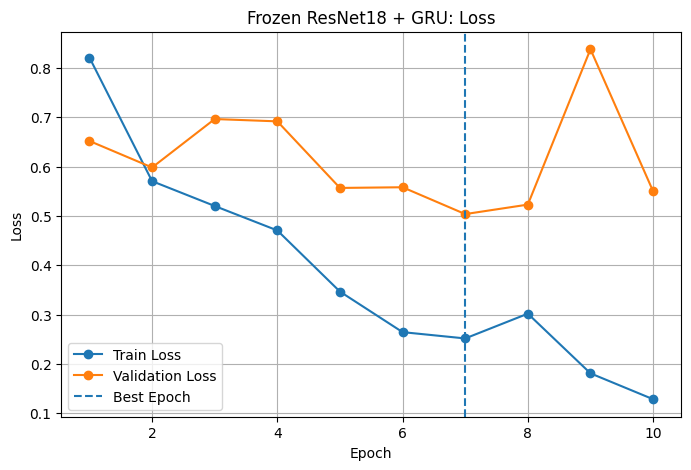

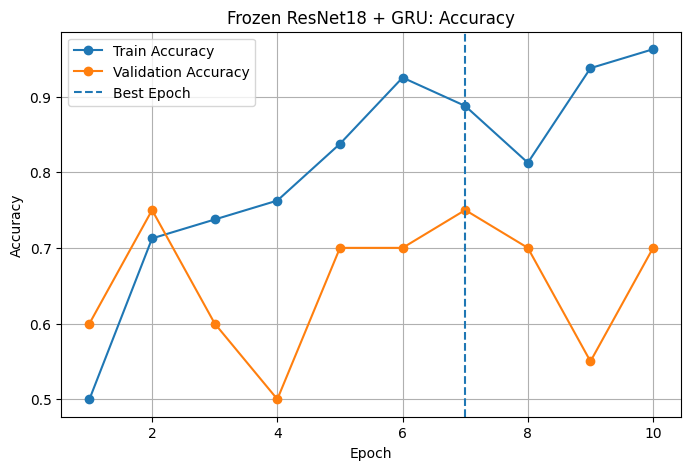

Frozen ResNet18 + GRU
Validation Loss: 0.5039
Validation Accuracy: 0.75
Macro F1: 0.7442

              precision    recall  f1-score   support

    Negative     0.6923    0.9000    0.7826        10
    Positive     0.8571    0.6000    0.7059        10

    accuracy                         0.7500        20
   macro avg     0.7747    0.7500    0.7442        20
weighted avg     0.7747    0.7500    0.7442        20



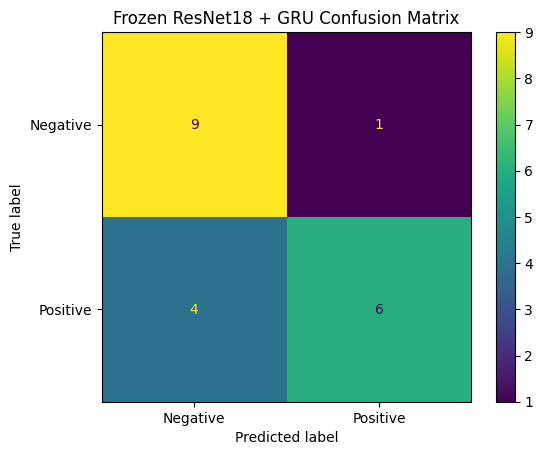

,video_id,true_label,predicted_label,predicted_probability,positive_probability
0,00003,positive,positive,0.932808,0.932808
1,00008,positive,negative,0.549638,0.450362
2,00010,positive,positive,0.571337,0.571337
3,00013,positive,positive,0.976092,0.976092
4,00018,positive,positive,0.902391,0.902391
5,00025,positive,positive,0.852137,0.852137
6,00032,positive,negative,0.721628,0.278372
7,00037,positive,negative,0.814994,0.185006
8,00046,positive,positive,0.981407,0.981407
9,00059,positive,negative,0.690950,0.309050


Moderate overfitting warning: the train result is noticeably higher than validation.


In [21]:
load_best_checkpoint(
    temporal_model=baseline_gru,
    feature_extractor=(
        baseline_feature_extractor
    ),
    checkpoint_path=BASELINE_GRU_PATH,
)

plot_training_history(
    history=baseline_history,
    best_epoch=(
        baseline_summary["best_epoch"]
    ),
    experiment_name=(
        "Frozen ResNet18 + GRU"
    ),
)

(
    baseline_metrics,
    baseline_predictions,
    baseline_labels,
    baseline_predicted_labels,
) = evaluate_temporal_model(
    temporal_model=baseline_gru,
    feature_extractor=(
        baseline_feature_extractor
    ),
    data_loader=val_loader,
    criterion=criterion,
)

show_evaluation(
    experiment_name=(
        "Frozen ResNet18 + GRU"
    ),
    metrics=baseline_metrics,
    labels=baseline_labels,
    predictions=(
        baseline_predicted_labels
    ),
)

display(
    baseline_predictions.head(10)
)

print(
    describe_overfitting(
        baseline_summary[
            "train_val_gap"
        ]
    )
)

# Experiment 2: Five-Fold Cross-Validation

Cross-validation evaluates whether the baseline result is stable across different data splits.

The 80 official train videos and 20 official validation videos are combined into 100 labeled videos only for this analysis. Five independent models are trained from scratch. In every fold, approximately 80 videos are used for training and 20 different videos are used for validation.

The split is stratified by class and created at the video level. Cross-validation does not produce the final delivered model. It estimates average validation performance, variation between splits, and the average train-validation gap.

In [ ]:
full_labeled_df = pd.concat(
    [
        train_df,
        val_df,
    ],
    ignore_index=True,
)

video_table = (
    full_labeled_df
    .groupby("video_id", as_index=False)
    .agg(label=("label", "first"))
)

video_table["target"] = (
    video_table["label"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(LABEL_TO_INDEX)
)

assert video_table["target"].notna().all()

print(
    "Total labeled videos:",
    len(video_table),
)

display(
    video_table["label"].value_counts()
)

Total labeled videos: 100


,count
label,
positive,50
negative,50


In [ ]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

cv_results = []

# One frozen feature extractor can be reused
# because its weights never change.
cv_feature_extractor = (
    ResNet18FeatureExtractor(
        fine_tune_layer4=False
    ).to(device)
)

for fold, (
    train_indices,
    val_indices,
) in enumerate(
    skf.split(
        video_table["video_id"],
        video_table["target"],
    ),
    start=1,
):

    print()
    print("=" * 60)
    print(f"Cross-validation fold {fold}/{N_SPLITS}")
    print("=" * 60)

    fold_seed = SEED + fold
    set_seed(fold_seed)

    fold_train_video_ids = set(
        video_table.iloc[
            train_indices
        ]["video_id"]
    )

    fold_val_video_ids = set(
        video_table.iloc[
            val_indices
        ]["video_id"]
    )

    fold_train_df = full_labeled_df[
        full_labeled_df["video_id"].isin(
            fold_train_video_ids
        )
    ].copy()

    fold_val_df = full_labeled_df[
        full_labeled_df["video_id"].isin(
            fold_val_video_ids
        )
    ].copy()

    (
        fold_train_dataset,
        fold_val_dataset,
        fold_train_loader,
        fold_val_loader,
    ) = make_video_loaders(
        train_data=fold_train_df,
        val_data=fold_val_df,
        seed=fold_seed,
    )

    print(
        "Train videos:",
        len(fold_train_dataset),
    )

    print(
        "Validation videos:",
        len(fold_val_dataset),
    )

    fold_model = GRUTemporalModel().to(
        device
    )

    fold_optimizer = torch.optim.Adam(
        fold_model.parameters(),
        lr=TEMPORAL_LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    fold_checkpoint_path = (
        TEMP_DIR
        / f"cv_gru_fold_{fold}.pth"
    )

    (
        fold_history,
        fold_summary,
    ) = train_temporal_experiment(
        temporal_model=fold_model,
        feature_extractor=(
            cv_feature_extractor
        ),
        train_loader=fold_train_loader,
        val_loader=fold_val_loader,
        optimizer=fold_optimizer,
        criterion=criterion,
        checkpoint_path=(
            fold_checkpoint_path
        ),
        max_epochs=MAX_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
        fine_tune_cnn=False,
        experiment_name=f"GRU CV Fold {fold}",
    )

    load_best_checkpoint(
        temporal_model=fold_model,
        feature_extractor=(
            cv_feature_extractor
        ),
        checkpoint_path=(
            fold_checkpoint_path
        ),
    )

    (
        fold_metrics,
        fold_predictions,
        fold_labels,
        fold_predicted_labels,
    ) = evaluate_temporal_model(
        temporal_model=fold_model,
        feature_extractor=(
            cv_feature_extractor
        ),
        data_loader=fold_val_loader,
        criterion=criterion,
    )

    cv_results.append({
        "fold": fold,
        "best_epoch":
            fold_summary["best_epoch"],
        "train_accuracy_at_best":
            fold_summary[
                "train_accuracy_at_best"
            ],
        "val_accuracy":
            fold_metrics["accuracy"],
        "macro_f1":
            fold_metrics["macro_f1"],
        "val_loss":
            fold_metrics["loss"],
        "train_val_gap":
            fold_summary["train_val_gap"],
    })


    if fold_checkpoint_path.exists():
        fold_checkpoint_path.unlink()

    del (
        fold_model,
        fold_optimizer,
        fold_train_loader,
        fold_val_loader,
        fold_train_dataset,
        fold_val_dataset,
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Cross-validation fold 1/5
Train videos: 80
Validation videos: 20
GRU CV Fold 1 | Epoch 1/15 | Train Loss: 0.8605 | Train Accuracy: 0.5375 | Val Loss: 0.6881 | Val Accuracy: 0.5000
Best score checkpoint saved
GRU CV Fold 1 | Epoch 2/15 | Train Loss: 0.6069 | Train Accuracy: 0.6625 | Val Loss: 0.6431 | Val Accuracy: 0.5000
Best score checkpoint saved
GRU CV Fold 1 | Epoch 3/15 | Train Loss: 0.5959 | Train Accuracy: 0.6750 | Val Loss: 0.6810 | Val Accuracy: 0.6000
Best score checkpoint saved
GRU CV Fold 1 | Epoch 4/15 | Train Loss: 0.4746 | Train Accuracy: 0.8250 | Val Loss: 0.5549 | Val Accuracy: 0.7500
Best score checkpoint saved
GRU CV Fold 1 | Epoch 5/15 | Train Loss: 0.3808 | Train Accuracy: 0.8750 | Val Loss: 0.5023 | Val Accuracy: 0.7500
Best score checkpoint saved
GRU CV Fold 1 | Epoch 6/15 | Train Loss: 0.3200 | Train Accuracy: 0.8500 | Val Loss: 0.9267 | Val Accuracy: 0.5500
Epochs without score improvement: 1
GRU CV Fold 1 | Epoch 7/15 | Train Loss: 0.3276 | Train Accuracy: 0.

# Experiment 3: Fine-Tuned ResNet18 Layer4 + GRU

This experiment tests whether adapting the final ResNet18 block to accident scenes improves performance.

All earlier ResNet blocks remain frozen. Only `layer4` and the GRU are trainable. The GRU learning rate is `1e-3`, while the layer4 learning rate is `1e-5`. ResNet18 stays in evaluation mode so its BatchNorm statistics do not change.

### Fine-Tuned Model Setup

This cell creates a fresh feature extractor with trainable `layer4`, a fresh GRU, and an optimizer with separate learning rates for the temporal model and ResNet block.

In [ ]:
set_seed(SEED)

finetuned_feature_extractor = (
    ResNet18FeatureExtractor(
        fine_tune_layer4=True
    ).to(device)
)

finetuned_gru = GRUTemporalModel().to(
    device
)

finetuned_optimizer = torch.optim.Adam([
    {
        "params":
            finetuned_gru.parameters(),
        "lr":
            TEMPORAL_LEARNING_RATE,
        "weight_decay":
            WEIGHT_DECAY,
    },
    {
        "params":
            finetuned_feature_extractor
            .resnet
            .layer4
            .parameters(),
        "lr":
            FINETUNE_LEARNING_RATE,
        "weight_decay":
            WEIGHT_DECAY,
    },
])

print(
    "Trainable ResNet parameters:",
    count_trainable_parameters(
        finetuned_feature_extractor
    ),
)

print(
    "Trainable GRU parameters:",
    count_trainable_parameters(
        finetuned_gru
    ),
)

Trainable ResNet parameters: 8393728
Trainable GRU parameters: 246786


In [ ]:
(
    finetuned_history,
    finetuned_summary,
) = train_temporal_experiment(
    temporal_model=finetuned_gru,
    feature_extractor=(
        finetuned_feature_extractor
    ),
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=finetuned_optimizer,
    criterion=criterion,
    checkpoint_path=FINETUNED_GRU_PATH,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    fine_tune_cnn=True,
    experiment_name=(
        "Fine-tuned layer4 + GRU"
    ),
)

Fine-tuned layer4 + GRU | Epoch 1/15 | Train Loss: 0.7581 | Train Accuracy: 0.5375 | Val Loss: 0.8696 | Val Accuracy: 0.5000
Best score checkpoint saved
Fine-tuned layer4 + GRU | Epoch 2/15 | Train Loss: 0.5640 | Train Accuracy: 0.7750 | Val Loss: 0.5886 | Val Accuracy: 0.6000
Best score checkpoint saved
Fine-tuned layer4 + GRU | Epoch 3/15 | Train Loss: 0.3971 | Train Accuracy: 0.7750 | Val Loss: 0.9066 | Val Accuracy: 0.6000
Epochs without score improvement: 1
Fine-tuned layer4 + GRU | Epoch 4/15 | Train Loss: 0.2133 | Train Accuracy: 0.9500 | Val Loss: 0.6697 | Val Accuracy: 0.7000
Best score checkpoint saved
Fine-tuned layer4 + GRU | Epoch 5/15 | Train Loss: 0.0763 | Train Accuracy: 0.9750 | Val Loss: 1.2699 | Val Accuracy: 0.5500
Epochs without score improvement: 1
Fine-tuned layer4 + GRU | Epoch 6/15 | Train Loss: 0.0896 | Train Accuracy: 0.9750 | Val Loss: 0.7230 | Val Accuracy: 0.5500
Epochs without score improvement: 2
Fine-tuned layer4 + GRU | Epoch 7/15 | Train Loss: 0.0336 

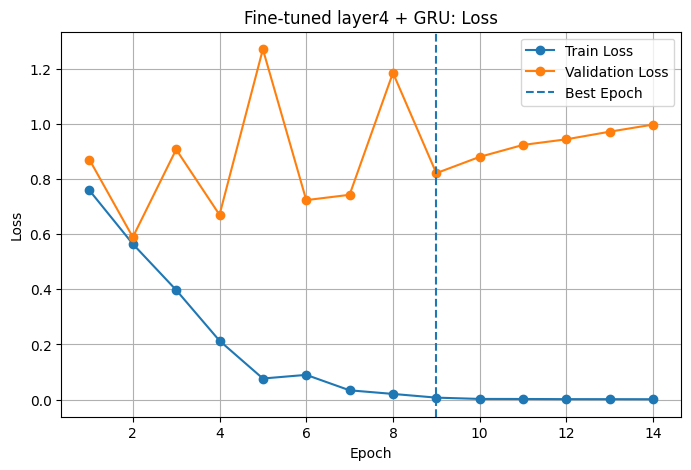

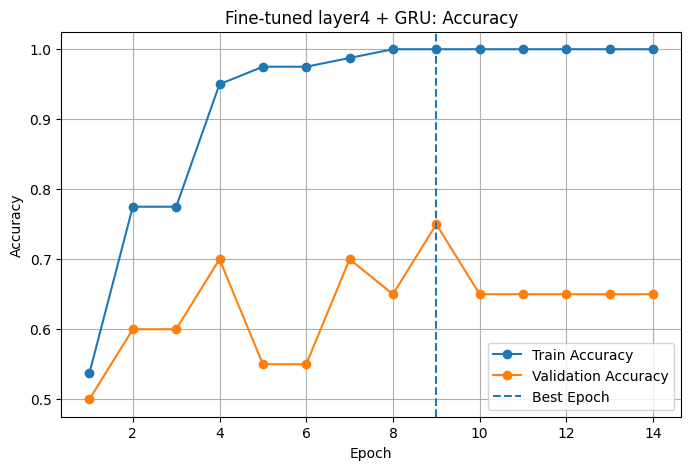

Fine-tuned layer4 + GRU
Validation Loss: 0.8207
Validation Accuracy: 0.75
Macro F1: 0.7494

              precision    recall  f1-score   support

    Negative     0.7273    0.8000    0.7619        10
    Positive     0.7778    0.7000    0.7368        10

    accuracy                         0.7500        20
   macro avg     0.7525    0.7500    0.7494        20
weighted avg     0.7525    0.7500    0.7494        20



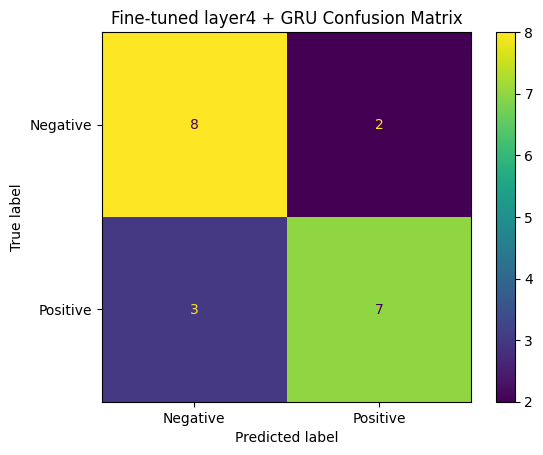

,video_id,true_label,predicted_label,predicted_probability,positive_probability
0,00003,positive,positive,0.997361,0.997361
1,00008,positive,positive,0.989204,0.989204
2,00010,positive,positive,0.975384,0.975384
3,00013,positive,positive,0.998738,0.998738
4,00018,positive,positive,0.997349,0.997349
5,00025,positive,positive,0.981430,0.981430
6,00032,positive,negative,0.933606,0.066394
7,00037,positive,negative,0.985345,0.014655
8,00046,positive,positive,0.999010,0.999010
9,00059,positive,negative,0.877786,0.122214


Strong overfitting warning: the train-validation accuracy gap is large.


In [ ]:
load_best_checkpoint(
    temporal_model=finetuned_gru,
    feature_extractor=(
        finetuned_feature_extractor
    ),
    checkpoint_path=FINETUNED_GRU_PATH,
)

plot_training_history(
    history=finetuned_history,
    best_epoch=(
        finetuned_summary["best_epoch"]
    ),
    experiment_name=(
        "Fine-tuned layer4 + GRU"
    ),
)

(
    finetuned_metrics,
    finetuned_predictions,
    finetuned_labels,
    finetuned_predicted_labels,
) = evaluate_temporal_model(
    temporal_model=finetuned_gru,
    feature_extractor=(
        finetuned_feature_extractor
    ),
    data_loader=val_loader,
    criterion=criterion,
)

show_evaluation(
    experiment_name=(
        "Fine-tuned layer4 + GRU"
    ),
    metrics=finetuned_metrics,
    labels=finetuned_labels,
    predictions=(
        finetuned_predicted_labels
    ),
)

display(
    finetuned_predictions.head(10)
)

print(
    describe_overfitting(
        finetuned_summary[
            "train_val_gap"
        ]
    )
)

# Experiment 4: Frozen ResNet18 + LSTM

This experiment replaces GRU with LSTM while keeping ResNet18 frozen. The hidden size, training settings, official split, and evaluation metrics remain the same.

The purpose is to determine whether a different recurrent architecture models the video sequence more effectively.# Experiment 4: Frozen ResNet18 + LSTM

This experiment replaces GRU with LSTM while keeping the ResNet frozen and using the same hidden size and training settings.

In [ ]:
set_seed(SEED)

lstm_feature_extractor = (
    ResNet18FeatureExtractor(
        fine_tune_layer4=False
    ).to(device)
)

lstm_model = LSTMTemporalModel().to(
    device
)

lstm_optimizer = torch.optim.Adam(
    lstm_model.parameters(),
    lr=TEMPORAL_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(
    "Trainable ResNet parameters:",
    count_trainable_parameters(
        lstm_feature_extractor
    ),
)

print(
    "Trainable LSTM parameters:",
    count_trainable_parameters(
        lstm_model
    ),
)

Trainable ResNet parameters: 0
Trainable LSTM parameters: 328962


In [ ]:
(
    lstm_history,
    lstm_summary,
) = train_temporal_experiment(
    temporal_model=lstm_model,
    feature_extractor=(
        lstm_feature_extractor
    ),
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=lstm_optimizer,
    criterion=criterion,
    checkpoint_path=LSTM_MODEL_PATH,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
    fine_tune_cnn=False,
    experiment_name=(
        "Frozen ResNet18 + LSTM"
    ),
)

Frozen ResNet18 + LSTM | Epoch 1/15 | Train Loss: 0.8027 | Train Accuracy: 0.3875 | Val Loss: 0.6900 | Val Accuracy: 0.5000
Best score checkpoint saved
Frozen ResNet18 + LSTM | Epoch 2/15 | Train Loss: 0.6653 | Train Accuracy: 0.6250 | Val Loss: 0.6564 | Val Accuracy: 0.7500
Best score checkpoint saved
Frozen ResNet18 + LSTM | Epoch 3/15 | Train Loss: 0.6641 | Train Accuracy: 0.5625 | Val Loss: 0.6651 | Val Accuracy: 0.6000
Epochs without score improvement: 1
Frozen ResNet18 + LSTM | Epoch 4/15 | Train Loss: 0.6079 | Train Accuracy: 0.7875 | Val Loss: 0.6409 | Val Accuracy: 0.5500
Epochs without score improvement: 2
Frozen ResNet18 + LSTM | Epoch 5/15 | Train Loss: 0.5328 | Train Accuracy: 0.8250 | Val Loss: 0.6161 | Val Accuracy: 0.7500
Best score checkpoint saved
Frozen ResNet18 + LSTM | Epoch 6/15 | Train Loss: 0.4955 | Train Accuracy: 0.7875 | Val Loss: 0.8616 | Val Accuracy: 0.5000
Epochs without score improvement: 1
Frozen ResNet18 + LSTM | Epoch 7/15 | Train Loss: 0.5067 | Train

# 13. Final Model Comparison

Because of Google Colab’s usage limits and runtime interruptions, I could not rerun all experiments to regenerate the comparison table. However, the results had already been saved in the notebook outputs, so I manually entered them into the table.

In [ ]:
manual_comparison = pd.DataFrame([
    {
        "Model": "Frozen ResNet18 + GRU",
        "Best Epoch": 12,
        "Validation Accuracy": 0.85,
        "Macro F1": 0.849624,
        "Validation Loss": 0.417639,
        "Train Accuracy": 0.975,
        "Train-Validation Gap": 0.125,
        "CV Mean Accuracy": 0.78,
        "CV Std Accuracy": 0.075829
    },
    {
        "Model": "Fine-tuned Layer4 + GRU",
        "Best Epoch": 9,
        "Validation Accuracy": 0.75,
        "Macro F1": 0.749373,
        "Validation Loss": 0.820716,
        "Train Accuracy": 1.00,
        "Train-Validation Gap": 0.25,
        "CV Mean Accuracy": None,
        "CV Std Accuracy": None
    },
    {
        "Model": "Frozen ResNet18 + LSTM",
        "Best Epoch": 5,
        "Validation Accuracy": 0.75,
        "Macro F1": 0.733333,
        "Validation Loss": 0.616071,
        "Train Accuracy": 0.825,
        "Train-Validation Gap": 0.075,
        "CV Mean Accuracy": None,
        "CV Std Accuracy": None
    }
])

display(
    manual_comparison.round(4)
)

Frozen ResNet18 + GRU was selected as the final model because it achieved the best overall validation performance among the tested architectures. It obtained the highest validation accuracy of 85%, the highest Macro F1 score of approximately 0.85, and the lowest validation loss of approximately 0.42. These results show that the model not only produced more correct predictions, but also performed more consistently across both classes.

The dataset contains only 100 labeled videos, which is relatively small for training deep video models. Therefore, using a fully trainable visual backbone would create a high risk of overfitting. Freezing ResNet18 allowed the model to benefit from pretrained visual features while reducing the number of trainable parameters. The GRU then learned the temporal relationships between consecutive frame features without requiring a very large dataset.

The fine-tuned ResNet18 + GRU model reached 100% training accuracy, but its validation accuracy decreased to 75% and its train-validation gap increased to 25%. This indicates strong overfitting and shows that fine-tuning the CNN was not suitable for the limited dataset.

The LSTM model had a smaller train-validation gap, but its validation accuracy and Macro F1 score were both lower than those of the GRU model. This suggests that the additional complexity of LSTM did not provide a practical advantage for this dataset.

The five-fold cross-validation results of the frozen ResNet18 + GRU model also showed a mean validation accuracy of approximately 78%. Although the performance varied across folds, the model remained more reliable than the other tested alternatives. Considering validation performance, model complexity, computational cost, and the small size of the dataset, Frozen ResNet18 + GRU provided the best balance between learning capacity and generalization.

# 14. Final Export to Google Drive

The reviewed final model is **Frozen ResNet18 + GRU**.

This cell reloads its best temporary checkpoint, generates validation predictions from exactly the same weights, and saves only the two required delivery files:

- `models/cv/temporal_model.pth`
- `outputs/cv/temporal_validation_predictions.csv`

The `.pth` file contains the GRU and classifier state dictionary. The frozen pretrained ResNet18 feature extractor must be recreated with the same notebook architecture when the model is used later.

In [22]:
load_best_checkpoint(
    temporal_model=baseline_gru,
    feature_extractor=baseline_feature_extractor,
    checkpoint_path=BASELINE_GRU_PATH,
)

(
    final_metrics,
    final_predictions,
    final_labels,
    final_predicted_labels,
) = evaluate_temporal_model(
    temporal_model=baseline_gru,
    feature_extractor=baseline_feature_extractor,
    data_loader=val_loader,
    criterion=criterion,
)

final_predictions = final_predictions[
    [
        "video_id",
        "true_label",
        "predicted_label",
        "predicted_probability",
    ]
].copy()

FINAL_MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

FINAL_PREDICTIONS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

torch.save(
    baseline_gru.state_dict(),
    FINAL_MODEL_PATH,
)

final_predictions.to_csv(
    FINAL_PREDICTIONS_PATH,
    index=False,
)

assert FINAL_MODEL_PATH.exists()
assert FINAL_PREDICTIONS_PATH.exists()
assert len(final_predictions) == len(val_dataset)

print(
    "Final validation accuracy:",
    round(final_metrics["accuracy"], 4),
)

print(
    "Final Macro F1:",
    round(final_metrics["macro_f1"], 4),
)

print(
    "Saved model:",
    FINAL_MODEL_PATH,
)

print(
    "Saved predictions:",
    FINAL_PREDICTIONS_PATH,
)

print(
    "Prediction rows:",
    len(final_predictions),
)

display(final_predictions.head(10))

Final validation accuracy: 0.75
Final Macro F1: 0.7442
Saved model: /content/drive/MyDrive/AI_Project2/models/cv/temporal_model.pth
Saved predictions: /content/drive/MyDrive/AI_Project2/outputs/cv/temporal_validation_predictions.csv
Prediction rows: 20


,video_id,true_label,predicted_label,predicted_probability
0,00003,positive,positive,0.932808
1,00008,positive,negative,0.549638
2,00010,positive,positive,0.571337
3,00013,positive,positive,0.976092
4,00018,positive,positive,0.902391
5,00025,positive,positive,0.852137
6,00032,positive,negative,0.721628
7,00037,positive,negative,0.814994
8,00046,positive,positive,0.981407
9,00059,positive,negative,0.690950
